In [1]:
from stable_baselines3 import PPO, TD3
from sb3_contrib import TQC, RecurrentPPO
from stable_baselines3.common.env_util import make_vec_env
from rl4greencrab import evaluate_agent, multiConstAction, simulator, plot_agent, CentroidAgent
import pandas as pd
import numpy as np
import ray
from skopt import gp_minimize, gbrt_minimize 
from skopt.plots import plot_convergence, plot_objective
from rl4greencrab import TwoActNormalized, twoActEnv
import os
import glob
import re
import matplotlib.pyplot as plt

## Simulate agent actions in the environment

In [2]:
param_df = pd.read_csv('../data/posterior/params.csv')

### Constant Action

In [3]:
# read in GP-optimized constant action
x = pd.read_csv("../data/constant_action/constant_actions_result.csv").values[0].tolist()

In [ ]:
# create instance of env
config = {
        'random_start': True,
        'observation_type': "count",
        'control_randomness': True,
        'param_df': param_df
    }
evalEnv =  twoActEnv(config)

# turn action into agent
constant_agent = multiConstAction(env=evalEnv, action=np.array(x))
const_plot_agent = plot_agent(env_sim_df=None, 
                              agent_name='const_agent', 
                              env=evalEnv, 
                              agent=constant_agent, 
                              save_dir='.')

# run 500 simulations of environment and constant action "agent"                             
df = const_plot_agent.gen_env_sim_df(rep=500, obs_names=['crabs'])

# get just final timestep
df_subset = df[df['t'] == 99]

# save df
df_subset.to_csv('../data/constant_action/const_agent_simulations.csv', index=False)

### RL Policy

##### run ppo simulations

In [ ]:
ppo_files =  (
    glob.glob('../saved_agents/count/PPO*.zip') + glob.glob('../saved_agents/count-biomass-time/TD3*.zip') +
    glob.glob('../saved_agents/count-time/PPO*.zip') + glob.glob('../saved_agents/size-time/TD3*.zip')
)

for filepath in ppo_files:
    parts = filepath.split(os.sep)
    subfolder = parts[2]
    filename = parts[-1] 
    
    obs = filename.split('(')[1].split(')')[0]          # e.g., 'count'
    rep_num = re.search(r'-(\d+)\.zip$', filename).group(1)  # e.g., '2'

    config = {
        'random_start': True,
        'observation_type': obs,
        'control_randomness': True,
        'param_df': param_df
    }
    
    load_path = filepath.replace('.zip', '')
    out_dir = f'../data/rl_policies/{subfolder}'
    save_name = f'ppo_{subfolder}_sim_{rep_num}'        # e.g., 'ppo_count_sim_2'

    print(f"Running simulation for {filepath} -> {out_dir}/{save_name}.csv")

    evalEnv = TwoActNormalized(config)
    ppoAgent = PPO.load(load_path, device="cpu")

    ppo_plot_agent = plot_agent(
        env_sim_df=None,
        agent_name=save_name,
        env=evalEnv,
        agent=ppoAgent,
        save_dir=out_dir
    )
    ppo_plot_agent.save_dir = out_dir  # save directly to data/rl_policies/count/

    ppo_plot_agent.gen_env_sim_df(rep=500, obs_names=['crabs'])
    ppo_plot_agent.save_df(ppo_plot_agent.env_simulation_df, save_name)

print("All simulations complete.")

Running simulation for ../saved_agents/count/PPO-(count)-4.zip -> ../data/rl_policies/count/ppo_count_sim_4.csv
Running simulation for ../saved_agents/count/PPO-(count)-3.zip -> ../data/rl_policies/count/ppo_count_sim_3.csv
Running simulation for ../saved_agents/count/PPO-(count)-2.zip -> ../data/rl_policies/count/ppo_count_sim_2.csv
Running simulation for ../saved_agents/count/PPO-(count)-5.zip -> ../data/rl_policies/count/ppo_count_sim_5.csv
Running simulation for ../saved_agents/count/PPO-(count)-6.zip -> ../data/rl_policies/count/ppo_count_sim_6.csv
Running simulation for ../saved_agents/count/PPO-(count)-1.zip -> ../data/rl_policies/count/ppo_count_sim_1.csv
Running simulation for ../saved_agents/count/PPO-(count)-8.zip -> ../data/rl_policies/count/ppo_count_sim_8.csv
Running simulation for ../saved_agents/count/PPO-(count)-10.zip -> ../data/rl_policies/count/ppo_count_sim_10.csv
Running simulation for ../saved_agents/count/PPO-(count)-9.zip -> ../data/rl_policies/count/ppo_count_

##### run tqc simulations

In [8]:
tqc_files = (
    glob.glob('../saved_agents/count/TQC*.zip') + glob.glob('../saved_agents/count-biomass-time/TQC*.zip') +
    glob.glob('../saved_agents/count-time/TQC*.zip') + glob.glob('../saved_agents/size-time/TQC*.zip')
)

for filepath in tqc_files:
    parts = filepath.split(os.sep)
    subfolder = parts[2]
    filename = parts[-1]  
    
    obs = filename.split('(')[1].split(')')[0]          # e.g., 'count'
    rep_num = re.search(r'-(\d+)\.zip$', filename).group(1)  # e.g., '2'

    config = {
        'random_start': True,
        'observation_type': obs,
        'control_randomness': True,
        'param_df': param_df
    }
    
    load_path = filepath.replace('.zip', '')
    out_dir = f'../data/rl_policies/{subfolder}'
    save_name = f'tqc_{subfolder}_sim_{rep_num}'        # e.g., 'ppo_count_sim_2'

    print(f"Running simulation for {filepath} -> {out_dir}/{save_name}.csv")

    evalEnv = TwoActNormalized(config)
    tqcAgent = TQC.load(load_path, device="cpu")

    tqc_plot_agent = plot_agent(
        env_sim_df=None,
        agent_name=save_name,
        env=evalEnv,
        agent=tqcAgent,
        save_dir=out_dir
    )
    tqc_plot_agent.save_dir = out_dir  # save directly to data/rl_policies/count/

    obs_names = list(evalEnv.observation_space.spaces.keys())  # e.g. ['crabs', 'months']


    tqc_plot_agent.gen_env_sim_df(rep=500, obs_names=obs_names)
    tqc_plot_agent.save_df(tqc_plot_agent.env_simulation_df, save_name)

print("All simulations complete.")

Running simulation for ../saved_agents/count/TQC-(count)-7.zip -> ../data/rl_policies/count/tqc_count_sim_7.csv
Running simulation for ../saved_agents/count/TQC-(count)-9.zip -> ../data/rl_policies/count/tqc_count_sim_9.csv
Running simulation for ../saved_agents/count/TQC-(count)-8.zip -> ../data/rl_policies/count/tqc_count_sim_8.csv
Running simulation for ../saved_agents/count/TQC-(count)-6.zip -> ../data/rl_policies/count/tqc_count_sim_6.csv
Running simulation for ../saved_agents/count/TQC-(count)-1.zip -> ../data/rl_policies/count/tqc_count_sim_1.csv
Running simulation for ../saved_agents/count/TQC-(count)-2.zip -> ../data/rl_policies/count/tqc_count_sim_2.csv
Running simulation for ../saved_agents/count/TQC-(count)-5.zip -> ../data/rl_policies/count/tqc_count_sim_5.csv
Running simulation for ../saved_agents/count/TQC-(count)-4.zip -> ../data/rl_policies/count/tqc_count_sim_4.csv
Running simulation for ../saved_agents/count/TQC-(count)-10.zip -> ../data/rl_policies/count/tqc_count_s

##### run td3 simulations

In [7]:
td3_files =  (
    glob.glob('../saved_agents/count/TD3*.zip') + glob.glob('../saved_agents/count-biomass-time/TD3*.zip') +
    glob.glob('../saved_agents/count-time/TD3*.zip') + glob.glob('../saved_agents/size-time/TD3*.zip')
)

for filepath in td3_files:
    parts = filepath.split(os.sep)
    subfolder = parts[2]
    filename = parts[-1]  
    
    obs = filename.split('(')[1].split(')')[0]          # e.g., 'count'
    rep_num = re.search(r'-(\d+)\.zip$', filename).group(1)  # e.g., '2'

    config = {
        'random_start': True,
        'observation_type': obs,
        'control_randomness': True,
        'param_df': param_df
    }
    
    load_path = filepath.replace('.zip', '')
    out_dir = f'../data/rl_policies/{subfolder}'
    save_name = f'td3_{subfolder}_sim_{rep_num}'     

    print(f"Running simulation for {filepath} -> {out_dir}/{save_name}.csv")

    evalEnv = TwoActNormalized(config)
    td3Agent = TD3.load(load_path, device="cpu")

    td3_plot_agent = plot_agent(
        env_sim_df=None,
        agent_name=save_name,
        env=evalEnv,
        agent=td3Agent,
        save_dir=out_dir
    )
    td3_plot_agent.save_dir = out_dir  # save directly to data/rl_policies/count/

    td3_plot_agent.gen_env_sim_df(rep=500, obs_names=['crabs'])
    td3_plot_agent.save_df(td3_plot_agent.env_simulation_df, save_name)

print("All simulations complete.")

Running simulation for ../saved_agents/count/TD3-(count)-6.zip -> ../data/rl_policies/count/td3_count_sim_6.csv
Running simulation for ../saved_agents/count/TD3-(count)-1.zip -> ../data/rl_policies/count/td3_count_sim_1.csv
Running simulation for ../saved_agents/count/TD3-(count)-8.zip -> ../data/rl_policies/count/td3_count_sim_8.csv
Running simulation for ../saved_agents/count/TD3-(count)-9.zip -> ../data/rl_policies/count/td3_count_sim_9.csv
Running simulation for ../saved_agents/count/TD3-(count)-7.zip -> ../data/rl_policies/count/td3_count_sim_7.csv
Running simulation for ../saved_agents/count/TD3-(count)-4.zip -> ../data/rl_policies/count/td3_count_sim_4.csv
Running simulation for ../saved_agents/count/TD3-(count)-3.zip -> ../data/rl_policies/count/td3_count_sim_3.csv
Running simulation for ../saved_agents/count/TD3-(count)-2.zip -> ../data/rl_policies/count/td3_count_sim_2.csv
Running simulation for ../saved_agents/count/TD3-(count)-5.zip -> ../data/rl_policies/count/td3_count_si

In [20]:
df_td3_sub = df_td3[df_td3['t'] == 99]
df_ppo_sub = df[df['t'] == 99]
df_tqc_sub = df_tqc[df_tqc['t'] == 99]

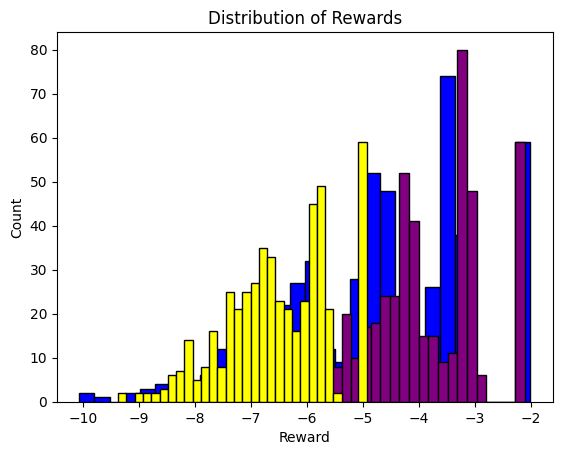

In [22]:
import matplotlib.pyplot as plt

plt.hist(df_td3_sub['rew'], bins=30, edgecolor='black', color = 'blue')
plt.hist(df_ppo_sub['rew'], bins=30, edgecolor='black', color = 'purple')
plt.hist(df_tqc_sub['rew'], bins=30, edgecolor='black', color = 'yellow')
plt.xlabel('Reward')
plt.ylabel('Count')
plt.title('Distribution of Rewards')
plt.show()

### Clustered Policy

In [6]:
centroids = pd.read_csv("../clustering/centroids.csv")

config = {
    'random_start': True,
    'observation_type': "count-biomass-time",
    'control_randomness': True,
    'param_df': param_df
}

evalEnv = TwoActNormalized(config)
centroid_agent = CentroidAgent(centroids=centroids, env=evalEnv)
centroid_plot_agent = plot_agent(env_sim_df=None,
                                 agent_name='centroid_agent',
                                 env=evalEnv,
                                 agent=centroid_agent,
                                 save_dir='.')
df = centroid_plot_agent.gen_env_sim_df(rep=500, obs_names=['crabs', 'months'])

In [7]:
# get just final timestep
df_subset = df[df['t'] == 99]
df_subset.to_csv('../data/cluster/clustered_sim.csv', index=False)
df_subset.head()

,t,crabs,months,act0,act1,rew,rep,crab_pop,nonlocal_crab
99,99,"[-0.98512, -0.6297414]",5,-0.964028,-0.039312,-10.361357,0,"[2.663242083228477e-23, 1.1911298023150381e-16...","[83432.83229840756, 39020.524608577325, 68148...."
199,99,"[-0.9854924, -0.65627265]",5,-0.964028,-0.039312,-11.371019,1,"[8.58831272971911e-19, 7.022628210949728e-13, ...","[83432.83229840756, 39020.524608577325, 68148...."
299,99,"[-0.9878564, -0.6782104]",5,-0.964028,-0.039312,-6.506405,2,"[6.230650374535664e-19, 4.959718757734706e-13,...","[83432.83229840756, 39020.524608577325, 68148...."
399,99,"[-0.9850552, -0.6311234]",5,-0.964028,-0.039312,-7.674080,3,"[2.023794363636195e-25, 1.2948290858265445e-17...","[83432.83229840756, 39020.524608577325, 68148...."
499,99,"[-0.98466665, -0.6395613]",5,-0.964028,-0.039312,-7.449139,4,"[1.1255511985173166e-36, 9.27760510858249e-27,...","[83432.83229840756, 39020.524608577325, 68148...."


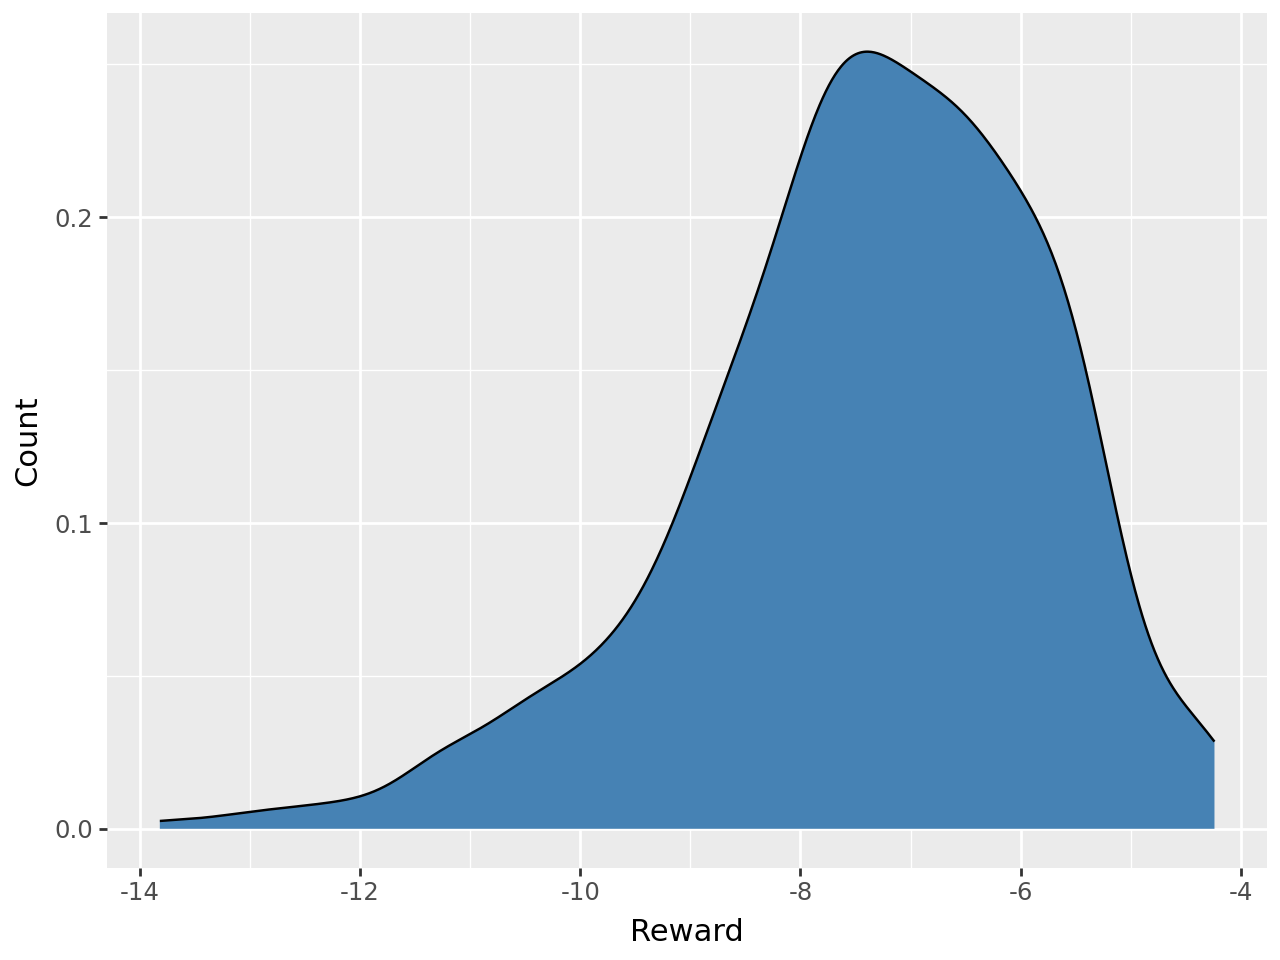

In [13]:
from plotnine import ggplot, aes, geom_density, labs

(
    ggplot(df_subset, aes(x='rew'))
    + geom_density(color='black', fill='steelblue')
    + labs(x='Reward', y='Count')
)



In [9]:
df_subset['rew'].mean()


np.float64(-7.402670824081728)